In [3]:
pip install sweetviz

   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.1 MB 3.2 MB/s eta 0:00:05
   -- ------------------------------------- 1.0/15.1 MB 2.7 MB/s eta 0:00:06
   --- ------------------------------------ 1.3/15.1 MB 2.3 MB/s eta 0:00:06
   ---- ----------------------------------- 1.8/15.1 MB 2.3 MB/s eta 0:00:06
   ----- ---------------------------------- 2.1/15.1 MB 2.2 MB/s eta 0:00:06
   ------ --------------------------------- 2.4/15.1 MB 2.1 MB/s eta 0:00:07
   ------ --------------------------------- 2.6/15.1 MB 2.0 MB/s eta 0:00:07
   ------- -------------------------------- 2.9/15.1 MB 1.9 MB/s eta 0:00:07
   -------- ------------------------------- 3.1/15.1 MB 1.8 MB/s eta 0:00:07
   --------- ------------------------------ 3.4/15.1 MB 1.7 MB/s eta 0:00:07
   ---------- ----------------------------- 3.9/15.1 MB 1.7 MB/s eta 0:00:07
   ----------- ---------------------------- 4.5/15.1 MB 1.8 MB/s eta 0:00:06
   ---

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed_data.csv')
print("Loaded:", df.shape)

Loaded: (850, 73)


In [3]:
# Distribution of total_loss_usd
fig = px.histogram(
    df.dropna(subset=['total_loss_usd']),
    x='total_loss_usd',
    nbins=50,
    title='Distribution of Total Breach Cost (USD)',
    labels={'total_loss_usd': 'Total Loss (USD)'}
)
fig.show()

# Key stats
print(df['total_loss_usd'].describe())
print(f"\nSkewness: {df['total_loss_usd'].skew():.2f}")

count    7.780000e+02
mean     7.099600e+07
std      2.151881e+08
min      1.737931e+05
25%      6.166441e+06
50%      1.656491e+07
75%      5.259585e+07
max      3.451548e+09
Name: total_loss_usd, dtype: float64

Skewness: 9.18


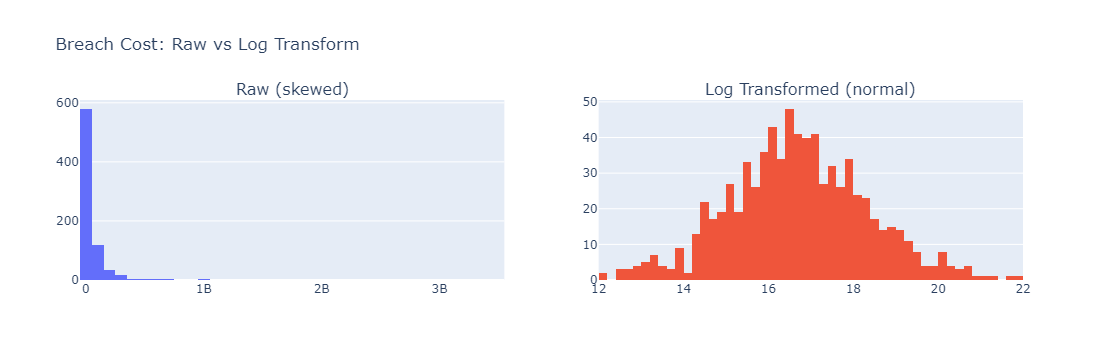

Log skewness: 0.07


In [7]:
df['total_loss_log'] = np.log1p(df['total_loss_usd'])

fig = make_subplots(rows=1, cols=2, subplot_titles=['Raw (skewed)', 'Log Transformed (normal)'])

fig.add_trace(
    go.Histogram(x=df['total_loss_usd'].dropna(), nbinsx=50, name='Raw'),
    row=1, col=1
)
fig.add_trace(
    go.Histogram(x=df['total_loss_log'].dropna(), nbinsx=50, name='Log'),
    row=1, col=2
)

fig.update_layout(title='Breach Cost: Raw vs Log Transform', showlegend=False)
fig.show()

print(f"Log skewness: {df['total_loss_log'].skew():.2f}")

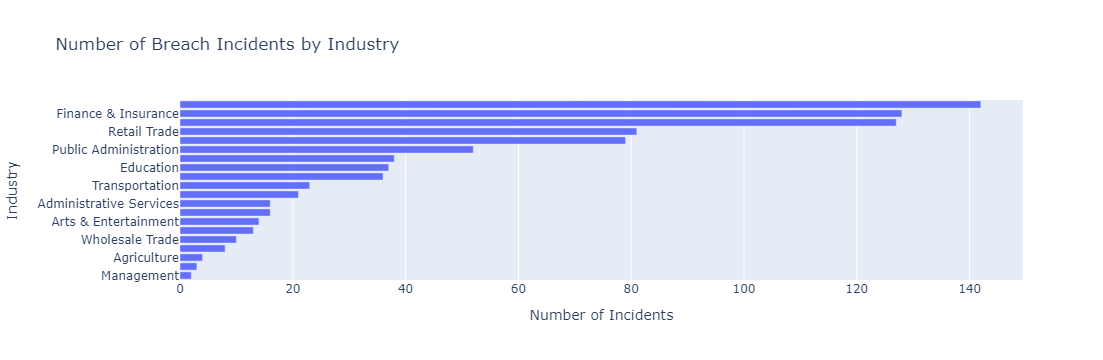

In [4]:
# Incidents by industry
industry_counts = df.groupby('industry_name').size().reset_index(name='incident_count')
industry_counts = industry_counts.sort_values('incident_count', ascending=True)

fig = px.bar(
    industry_counts,
    x='incident_count',
    y='industry_name',
    orientation='h',
    title='Number of Breach Incidents by Industry',
    labels={'incident_count': 'Number of Incidents', 'industry_name': 'Industry'}
)
fig.show()

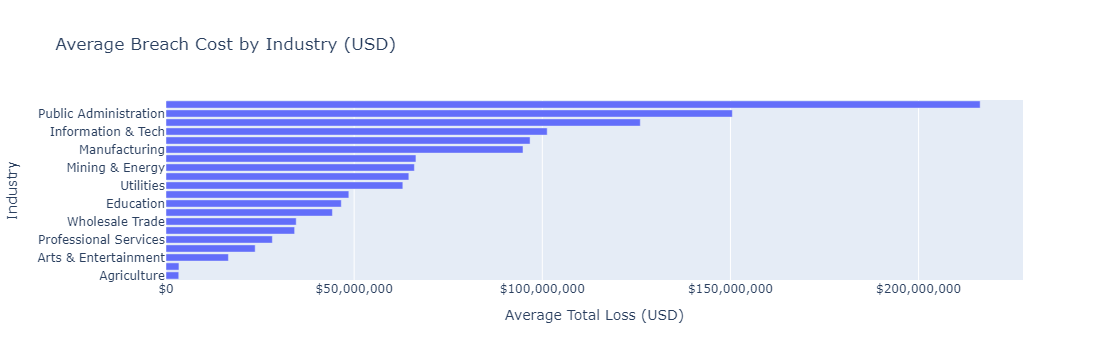

In [5]:
# Average breach cost by industry
industry_cost = df.groupby('industry_name')['total_loss_usd'].mean().reset_index()
industry_cost.columns = ['industry_name', 'avg_breach_cost']
industry_cost = industry_cost.dropna().sort_values('avg_breach_cost', ascending=True)

fig = px.bar(
    industry_cost,
    x='avg_breach_cost',
    y='industry_name',
    orientation='h',
    title='Average Breach Cost by Industry (USD)',
    labels={'avg_breach_cost': 'Average Total Loss (USD)', 'industry_name': 'Industry'}
)
fig.update_xaxes(tickformat='$,.0f')
fig.show()

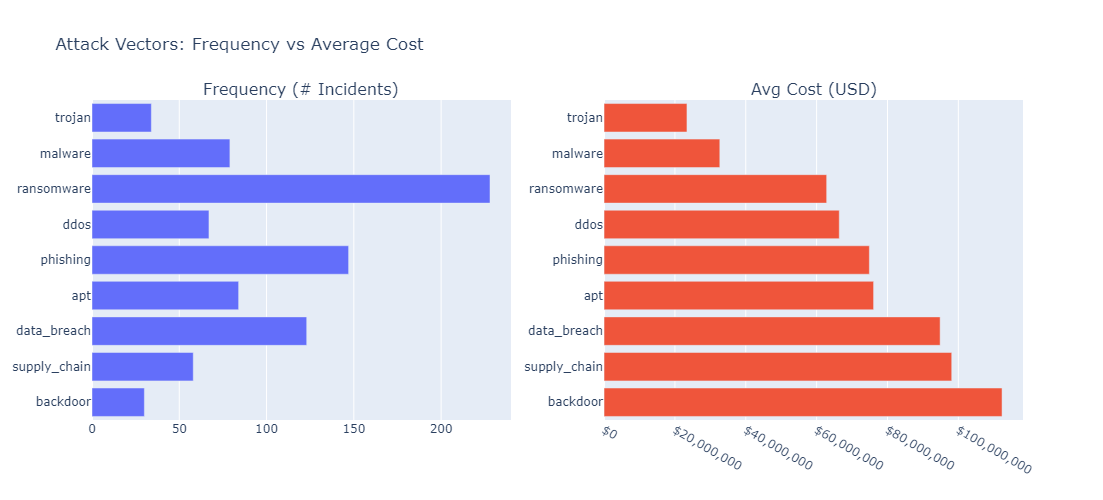

In [6]:
# Attack vector: frequency vs average cost side by side
attack_counts = df.groupby('attack_vector_primary').size().reset_index(name='incident_count')
attack_cost = df.groupby('attack_vector_primary')['total_loss_usd'].mean().reset_index()
attack_cost.columns = ['attack_vector_primary', 'avg_cost']

attack = attack_counts.merge(attack_cost, on='attack_vector_primary').sort_values('avg_cost', ascending=False)

fig = make_subplots(rows=1, cols=2, subplot_titles=['Frequency (# Incidents)', 'Avg Cost (USD)'])

fig.add_trace(
    go.Bar(x=attack['incident_count'], y=attack['attack_vector_primary'],
           orientation='h', name='Incidents'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=attack['avg_cost'], y=attack['attack_vector_primary'],
           orientation='h', name='Avg Cost'),
    row=1, col=2
)

fig.update_layout(title='Attack Vectors: Frequency vs Average Cost', showlegend=False, height=500)
fig.update_xaxes(tickformat='$,.0f', row=1, col=2)
fig.show()

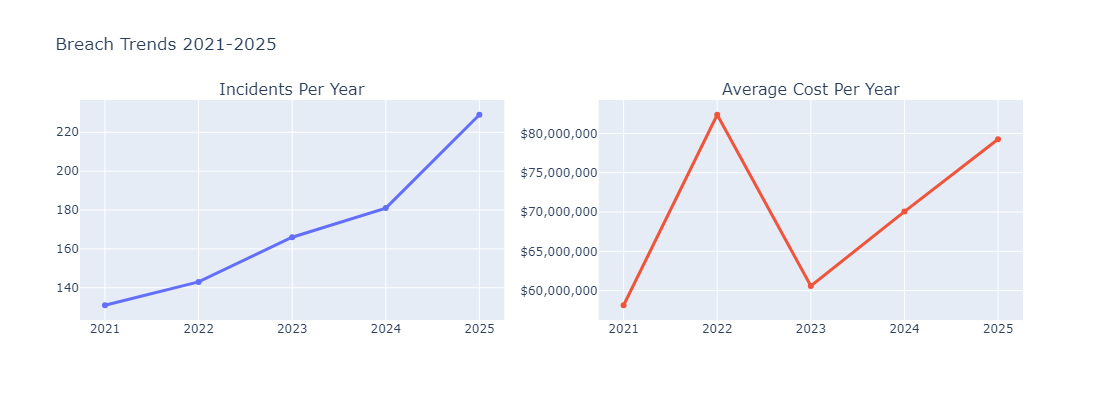

In [7]:
# Incidents and average cost by year
yearly = df.groupby('incident_year').agg(
    incident_count=('incident_id', 'count'),
    avg_cost=('total_loss_usd', 'mean')
).reset_index().dropna()

fig = make_subplots(rows=1, cols=2, subplot_titles=['Incidents Per Year', 'Average Cost Per Year'])

fig.add_trace(
    go.Scatter(x=yearly['incident_year'], y=yearly['incident_count'],
               mode='lines+markers', name='Incidents', line=dict(width=3)),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=yearly['incident_year'], y=yearly['avg_cost'],
               mode='lines+markers', name='Avg Cost', line=dict(width=3)),
    row=1, col=2
)

fig.update_layout(title='Breach Trends 2021-2025', showlegend=False, height=400)
fig.update_yaxes(tickformat='$,.0f', row=1, col=2)
fig.show()

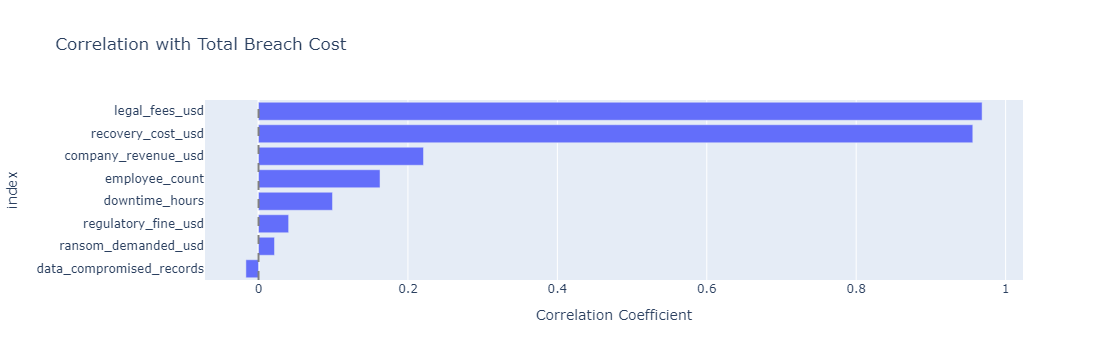

In [8]:
# What numeric factors correlate most with breach cost?
numeric_cols = [
    'total_loss_usd', 'company_revenue_usd', 'employee_count',
    'data_compromised_records', 'downtime_hours',
    'ransom_demanded_usd', 'recovery_cost_usd',
    'legal_fees_usd', 'regulatory_fine_usd'
]

corr = df[numeric_cols].corr()[['total_loss_usd']].drop('total_loss_usd')
corr = corr.sort_values('total_loss_usd', ascending=True)

fig = px.bar(
    corr,
    x='total_loss_usd',
    y=corr.index,
    orientation='h',
    title='Correlation with Total Breach Cost',
    labels={'total_loss_usd': 'Correlation Coefficient', 'y': 'Feature'}
)
fig.add_vline(x=0, line_dash='dash', line_color='gray')
fig.show()

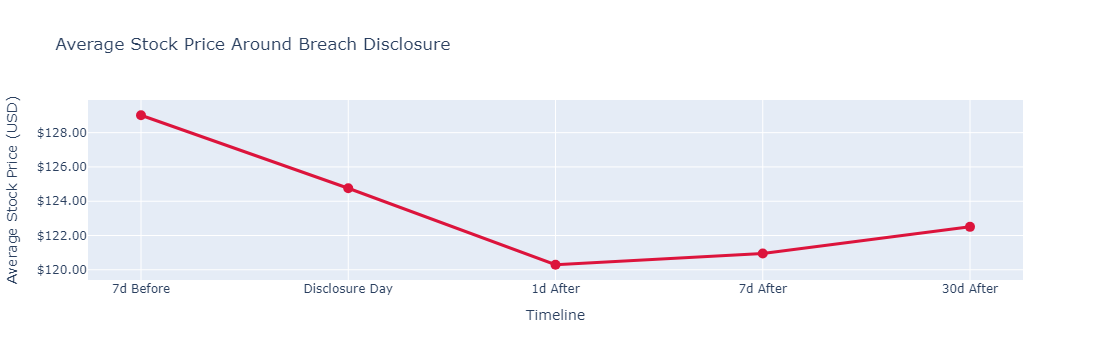

In [9]:
# Stock price behavior around breach disclosure
market_df = df.dropna(subset=['price_7d_before', 'price_disclosure_day', 'price_7d_after', 'price_30d_after'])

avg_prices = {
    '7d Before': market_df['price_7d_before'].mean(),
    'Disclosure Day': market_df['price_disclosure_day'].mean(),
    '1d After': market_df['price_1d_after'].mean(),
    '7d After': market_df['price_7d_after'].mean(),
    '30d After': market_df['price_30d_after'].mean()
}

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(avg_prices.keys()),
    y=list(avg_prices.values()),
    mode='lines+markers',
    line=dict(width=3, color='crimson'),
    marker=dict(size=10)
))
fig.update_layout(
    title='Average Stock Price Around Breach Disclosure',
    xaxis_title='Timeline',
    yaxis_title='Average Stock Price (USD)',
    yaxis_tickformat='$,.2f'
)
fig.show()